In [2]:
#order data cleaning 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#cleaning the order data set
"""
droping deriveled appoved date nan rows
chaning the data type to the date 
after droping there is one nan val in delivered date so fill it with the appored date for one col
keeping the delivered item only in the cleaned df
"""

In [ ]:

df_order_clean = pd.read_csv(r"../data/raw/olist_orders_dataset.csv")

# Filter non-delivered orders & drop missing delivery timestamps
df_order_clean = df_order_clean[df_order_clean['order_status'] == 'delivered'].copy()
df_order_clean.dropna(subset=['order_delivered_customer_date', 'order_approved_at'], inplace=True)

# Convert Date Columns
date_cols_orders = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_cols_orders:
    df_order_clean[col] = pd.to_datetime(df_order_clean[col])

df_order_clean.drop_duplicates(inplace=True)

#there is one nan val in carrier date
df_order_clean['order_delivered_carrier_date'] = df_order_clean['order_delivered_carrier_date'].fillna(df_order_clean['order_approved_at'])
df_order_clean.isnull().sum()
df_order_clean.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [ ]:
#product and category

#fill na val in categry with outro

#category data set and conatin same with englush name so megre it woth the prododuct dataset

#fill the nan value with the median in the weighr lenght height width

#also fiiling the name length and desvcription elgth with median for missing value

#photo qty with mode of 1st most repeated value

In [ ]:
df_product_clean = pd.read_csv(r"../data/raw/olist_products_dataset.csv")
df_category = pd.read_csv(r"../data/raw/product_category_name_translation.csv")

# Fill Categorical Missing Values
df_product_clean['product_category_name']=df_product_clean['product_category_name'].fillna('outro')

# Merge English Category Translation
df_product_clean = df_product_clean.merge(df_category, on='product_category_name', how='left')
df_product_clean["product_category_name_english"]=df_product_clean['product_category_name_english'].fillna('other')

# Fill Numerical Missing Values (Dimensions/Weight) with Median
num_cols_product = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_cols_product:
    df_product_clean[col]=df_product_clean[col].fillna(df_product_clean[col].median())
    
    
#text length features with median
df_product_clean['product_name_lenght']= df_product_clean['product_name_lenght'].fillna(df_product_clean['product_name_lenght'].median())
df_product_clean['product_description_lenght']= df_product_clean['product_description_lenght'].fillna(df_product_clean['product_description_lenght'].median())

# Impute photo quantity with mode (most frequent value = 1.0) or median
df_product_clean['product_photos_qty']= df_product_clean['product_photos_qty'].fillna(df_product_clean['product_photos_qty'].mode()[0])

df_product_clean.drop_duplicates(inplace=True)


In [7]:
df_product_clean.isnull().sum()



product_id                       0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64

In [ ]:
#order items

#changing the data type to time

#handling the outlier for the price anf fright value with out removing we only cap with the median


In [8]:
def cap_outliers_iqr(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (factor * IQR)
    upper_bound = Q3 + (factor * IQR)
    
    df[f'{column}_capped'] = np.where(
        df[column] > upper_bound, upper_bound,
        np.where(df[column] < lower_bound, lower_bound, df[column])
    )
    return df

In [ ]:


df_item_clean = pd.read_csv(r"../data/raw/olist_order_items_dataset.csv")

# Convert Date Column
df_item_clean['shipping_limit_date'] = pd.to_datetime(df_item_clean['shipping_limit_date'])

# Outlier Detection & Capping (IQR)
df_item_clean = cap_outliers_iqr(df_item_clean, 'price')
df_item_clean = cap_outliers_iqr(df_item_clean, 'freight_value')

df_item_clean.drop_duplicates(inplace=True)

df_item_clean

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140
...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720


In [10]:
df_item_clean.isnull().sum()

order_id                0
order_item_id           0
product_id              0
seller_id               0
shipping_limit_date     0
price                   0
freight_value           0
price_capped            0
freight_value_capped    0
dtype: int64

In [ ]:
#order payment

#creating new df with with tot pay as sum of pay ment by one cust
#installment by the order id
#payment type

In [12]:
df_pay_raw = pd.read_csv(r"../data/raw/olist_order_payments_dataset.csv")

df_pay_raw[df_pay_raw.duplicated()]

df_pay_raw.isnull().sum()

# Aggregate to order_id level to avoid Cartesian row duplication during merge
df_pay_clean = df_pay_raw.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    primary_payment_type=('payment_type', lambda x: x.mode()[0] if not x.empty else 'unknown')
    #dont want payment sqeuemtial here so dont added it
).reset_index()

df_pay_clean["payment_sequential"] =df_pay_raw["payment_sequential"]



In [13]:
df_pay_clean

,order_id,total_payment_value,max_installments,primary_payment_type,payment_sequential
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card,1
...,...,...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40,1,boleto,1
99436,fffcd46ef2263f404302a634eb57f7eb,386.53,1,boleto,1
99437,fffce4705a9662cd70adb13d4a31832d,116.85,3,credit_card,1
99438,fffe18544ffabc95dfada21779c9644f,64.71,3,credit_card,1


In [ ]:
#review
#here comment title and comment message with 87k and 58k nan val so drop the column we want only score
# Simply drop the columns
#new clean df iwth the order id , avg review score and review count 

In [15]:
df_review_raw = pd.read_csv(r"../data/raw/olist_order_reviews_dataset.csv")

#here comment title and comment message with 87k and 58k nan val so drop the column we want only score
# Simply drop the columns
cols_to_drop = ['review_comment_title', 'review_comment_message']
df_review_raw.drop(columns=cols_to_drop, errors='ignore', inplace=True)

# Remove duplicates
df_review_raw.drop_duplicates(inplace=True)

# Aggregate to order_id level
df_review_clean = df_review_raw.groupby('order_id').agg(
    avg_review_score=('review_score', 'mean'),
    review_count=('review_id', 'count')
).reset_index()

df_review_clean



,order_id,avg_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1
...,...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0,1
98669,fffcd46ef2263f404302a634eb57f7eb,5.0,1
98670,fffce4705a9662cd70adb13d4a31832d,5.0,1
98671,fffe18544ffabc95dfada21779c9644f,5.0,1


In [ ]:
#customer and seller
#keep the  the record as it is no diplicates and null

In [18]:
df_customer_clean = pd.read_csv(r"../data/raw/olist_customers_dataset.csv")
df_seller_clean = pd.read_csv(r"../data/raw/olist_sellers_dataset.csv")

#here no null val and duplicates 

In [19]:
df_customer_clean

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [20]:
df_seller_clean

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [ ]:
#merging all the cleaned df to one df

In [21]:
# Master Relational Join on Cleaned Datasets
df_master_cleaned = (
    df_item_clean
    .merge(df_order_clean, on='order_id', how='inner')
    .merge(df_customer_clean, on='customer_id', how='left')
    .merge(df_product_clean, on='product_id', how='left')
    .merge(df_seller_clean, on='seller_id', how='left')
    .merge(df_pay_clean, on='order_id', how='left')
    .merge(df_review_clean, on='order_id', how='left')
)

df_master_cleaned

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_capped,freight_value_capped,customer_id,...,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,max_installments,primary_payment_type,payment_sequential,avg_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,13.290,3ce436f183e68e07877b285a838db11a,...,cool_stuff,27277,volta redonda,SP,72.19,2.0,credit_card,1.0,5.0,1.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,19.930,f6dd3ec061db4e3987629fe6b26e5cce,...,pet_shop,3471,sao paulo,SP,259.83,3.0,credit_card,1.0,4.0,1.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,17.870,6489ae5e4333f3693df5ad4372dab6d3,...,furniture_decor,37564,borda da mata,MG,216.87,5.0,credit_card,1.0,5.0,1.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.790,d4eb9395c8c0431ee92fce09860c5a06,...,perfumery,14403,franca,SP,25.78,2.0,credit_card,1.0,4.0,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,18.140,58dbd0b2d70206bf40e62cd34e84d795,...,garden_tools,87900,loanda,PR,218.04,3.0,credit_card,1.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110169,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,277.40,33.255,b51593916b4b8e0d6f66f2ae24f2673d,...,housewares,88303,itajai,SC,343.40,1.0,boleto,1.0,5.0,1.0
110170,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,277.40,33.255,84c5d4fbaf120aae381fad077416eaa0,...,computers_accessories,1206,sao paulo,SP,386.53,1.0,boleto,1.0,5.0,1.0
110171,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,99.90,16.950,29309aa813182aaddc9b259e31b870e6,...,sports_leisure,80610,curitiba,PR,116.85,3.0,credit_card,1.0,5.0,1.0
110172,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,55.99,8.720,b5e6afd5a41800fdf401e0272ca74655,...,computers_accessories,4733,sao paulo,SP,64.71,3.0,credit_card,1.0,5.0,1.0


In [ ]:
#fill the missing val of review counat review score to 0 cuz they didnt give any review 
#adding the median or node would affect the data qualty so going with the zero

In [22]:
# No review submitted
df_master_cleaned['review_count'] = df_master_cleaned['review_count'].fillna(0)

# No review score available
df_master_cleaned['avg_review_score'] = df_master_cleaned['avg_review_score'].fillna(0)

In [ ]:
#total payemt max installemnt payment type sequtinal with the median mode 

In [23]:
#total payment
df_master_cleaned['total_payment_value'] = df_master_cleaned['total_payment_value'].fillna(
    df_master_cleaned['total_payment_value'].median()
)

In [24]:
#max installation
df_master_cleaned['max_installments'] = df_master_cleaned['max_installments'].fillna(
    df_master_cleaned['max_installments'].median()
)

In [25]:
#primary payment type
df_master_cleaned['primary_payment_type'] = df_master_cleaned['primary_payment_type'].fillna(
    df_master_cleaned['primary_payment_type'].mode()[0]
)

In [26]:
#payment sequential
df_master_cleaned['payment_sequential'] = df_master_cleaned['payment_sequential'].fillna(
    df_master_cleaned['payment_sequential'].median()
)

In [27]:
df_master_cleaned.isnull().sum()

order_id                         0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
price_capped                     0
freight_value_capped             0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_nam

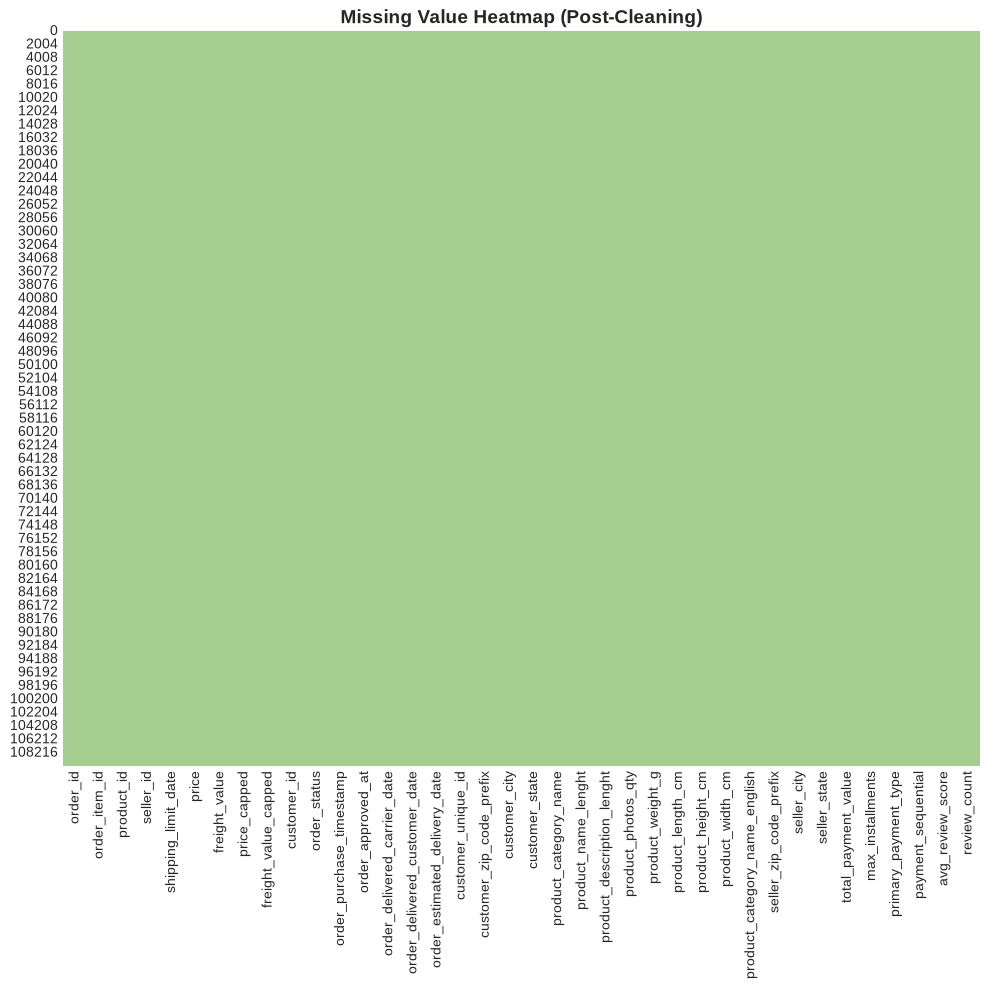

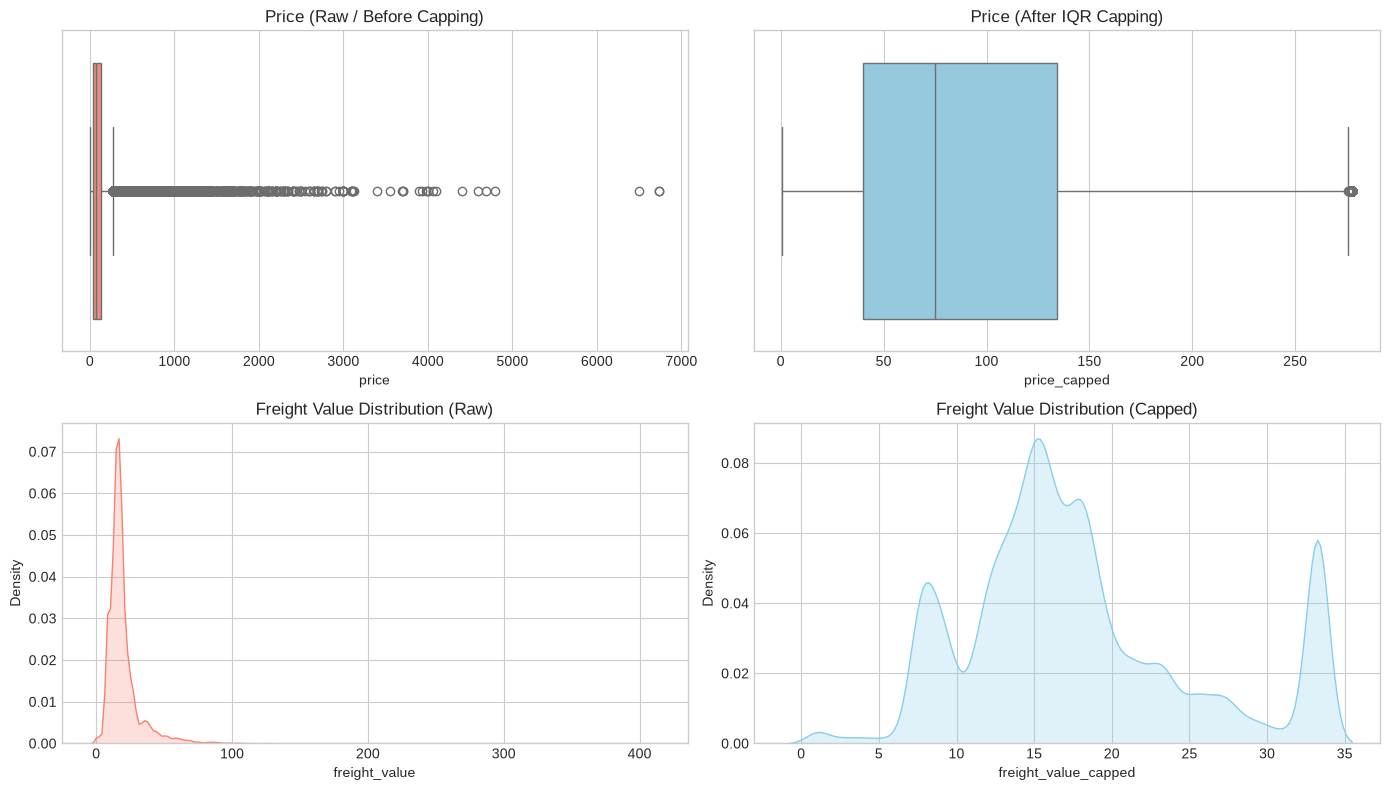

In [28]:
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


# 1. Missing Value Heatmap (Post-Cleaning Verification)
plt.figure(figsize=(10, 10))
sns.heatmap(df_master_cleaned.isnull(), cbar=False, cmap='crest')
plt.title('Missing Value Heatmap (Post-Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Before vs After IQR Outlier Treatment (Box Plots & Distributions)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Price Comparison
sns.boxplot(ax=axes[0, 0], x=df_master_cleaned['price'], color='salmon').set_title('Price (Raw / Before Capping)')
sns.boxplot(ax=axes[0, 1], x=df_master_cleaned['price_capped'], color='skyblue').set_title('Price (After IQR Capping)')

# Freight Comparison
sns.kdeplot(ax=axes[1, 0], x=df_master_cleaned['freight_value'], color='salmon', fill=True).set_title('Freight Value Distribution (Raw)')
sns.kdeplot(ax=axes[1, 1], x=df_master_cleaned['freight_value_capped'], color='skyblue', fill=True).set_title('Freight Value Distribution (Capped)')

plt.tight_layout()
plt.show()

In [ ]:
#changing the datatype to category for the catigorical column

In [29]:
categorical_columns = [
    'customer_city',
    'customer_state',
    'seller_city',
    'seller_state',
    'order_status',
    'primary_payment_type',
    'product_category_name',
    'product_category_name_english'
]

for col in categorical_columns:
    df_master_cleaned[col] = df_master_cleaned[col].astype('category')
    
df_master_cleaned[categorical_columns].dtypes

customer_city                    category
customer_state                   category
seller_city                      category
seller_state                     category
order_status                     category
primary_payment_type             category
product_category_name            category
product_category_name_english    category
dtype: object

In [30]:
#relationship
df_master_cleaned[['order_id','customer_id','product_id','seller_id']].isnull().sum()

df_master_cleaned.duplicated(subset=['order_id','order_item_id']).sum()

np.int64(0)

In [ ]:
print(f"Total Processed Rows: {len(df_master_cleaned):,}")
print(f"Total Columns: {df_master_cleaned.shape[1]}")
print(f"Remaining Missing Values: {df_master_cleaned.isnull().sum().sum()}")


=== PHASE 2 DATA QUALITY AUDIT SUMMARY ===
Total Processed Rows: 110,174
Total Columns: 38
Remaining Missing Values: 0


In [32]:
df_master_cleaned.to_csv(r"../data/cleaned/df_master_cleaned.csv", index=False)

In [35]:
df_master_cleaned.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'price_capped',
       'freight_value_capped', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'total_payment_value',
       'max_installments', 'primary_payment_type', 'payment_sequential',
       'avg_review_score', 'review_count'],
      dtype='str')